In [1]:
import os
import glob
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

import torch
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchsummary import summary
import torch.optim as optim

from lib.dataset.dataloader import SICDataLoader


In [2]:
# Load data (update this path to your .nc directory)
sic_loader = SICDataLoader(
    # data_dirs=['/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/','/dmidata/projects/asip-cms/reproc/'],
    data_dirs=['Data/AMSR2', 'Data/SIC'],
    batch_size=1,
    shuffle=False,
    date_pattern=r'(\d{8})[T]\d{6}',
)


In [3]:
def extract_matched_statistics(loader):
    all_stats = []

    matched_pairs = loader.get_matched_pairs_info()

    # Iterate through every matched date pair
    for pair in matched_pairs:
        date_str = pair['date']
        
        # Process each AMSR2 file in this pair
        for amsr2_path in pair['amsr2_files']:
            amsr2_path = "\\\\?\\" + os.path.abspath(Path(amsr2_path).as_posix())
            amsr2_info = loader._load_amsr2(amsr2_path)
            num_swaths = amsr2_info['num_swaths']
            
            # Process each SIC file in this pair
            for sic_path in pair['sic_files']:
                sic_path = "\\\\?\\" + os.path.abspath(Path(sic_path).as_posix())
                sic_info = loader._load_sic(sic_path)
                
                # Extract band 1 data
                # Ensure we handle NaNs so they aren't counted in bins
                band1 = sic_info['band']['band_1']
                valid_pixels = band1[~np.isnan(band1)]
                
                # Define our bins: [0, 0.001, 10, 20, ..., 100]
                # We use a tiny number (0.001) to separate exactly 0 from the 0-10 range
                bins = [0, 0.001, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
                counts, _ = np.histogram(valid_pixels, bins=bins)
                
                # Map counts to the requested labels
                pixel_distribution = {
                    'val_0':     int(counts[0]),
                    '0-10':      int(counts[1]),
                    '10-20':     int(counts[2]),
                    '20-30':     int(counts[3]),
                    '30-40':     int(counts[4]),
                    '40-50':     int(counts[5]),
                    '50-60':     int(counts[6]),
                    '60-70':     int(counts[7]),
                    '70-80':     int(counts[8]),
                    '80-90':     int(counts[9]),
                    '90-100':    int(counts[10]),
                }

                # Combine everything into one record
                record = {
                    'timestamp': date_str,
                    'amsr2_file': os.path.basename(amsr2_path),
                    'sic_file': os.path.basename(sic_path),
                    'num_swaths': num_swaths,
                    'bbox': sic_info['bbox'],
                    **pixel_distribution # Unpacks the dictionary of counts
                }
                
                all_stats.append(record)
                
    return all_stats

In [4]:
# Assuming your loader is already initialized as 'loader'
stats_list = extract_matched_statistics(sic_loader)

# Optional: Convert to a DataFrame for easy viewing/saving
df = pd.DataFrame(stats_list)
print(df.head())

# Save to CSV if needed
# df.to_csv("sic_amsr2_metadata_stats.csv", index=False)

         timestamp                                         amsr2_file  \
0  20190823T033023  AMSR2_S1A_EW_GRDM_1SDH_20190823T033023_2019082...   

                                            sic_file  num_swaths  \
0  S1A_EW_GRDM_1SDH_20190823T033023_20190823T0331...           2   

                                                bbox  val_0  0-10  10-20  \
0  (865560.1090439522, 79150.06016295675, 1349627...      0     0      0   

   20-30  30-40  40-50  50-60  60-70  70-80  80-90  90-100  
0      0      0      0      0      0      0      0       0  


In [5]:
amsr2_file = sic_loader.get_matched_pairs_info()[0]['amsr2_files'][0]
amsr2_file = "\\\\?\\" + os.path.abspath(Path(amsr2_file).as_posix())

sic_file = sic_loader.get_matched_pairs_info()[0]['sic_files'][0]
sic_file = "\\\\?\\" + os.path.abspath(Path(sic_file).as_posix())

print(f"AMSR2 file: {amsr2_file}")
print(f"SIC file: {sic_file}")

AMSR2 file: \\?\c:\Users\ninna\OneDrive - Danmarks Tekniske Universitet\Sikkerhedskopiering\Dokumenter\Uni\Master\Master thesis - Super-resolution sea ice concentration using generative AI\Code\Data\AMSR2\AMSR2_S1A_EW_GRDM_1SDH_20190823T033023_20190823T033127_028691_033F56_7A1D.nc
SIC file: \\?\c:\Users\ninna\OneDrive - Danmarks Tekniske Universitet\Sikkerhedskopiering\Dokumenter\Uni\Master\Master thesis - Super-resolution sea ice concentration using generative AI\Code\Data\SIC\S1A_EW_GRDM_1SDH_20190823T033023_20190823T033127_028691_033F56_7A1D_SIC.tiff


In [6]:
ds = xr.open_dataset(amsr2_file, engine='netcdf4')
ds

<xarray.Dataset> Size: 5MB
Dimensions:             (dim_0: 214, dim_1: 209)
Dimensions without coordinates: dim_0, dim_1
Data variables: (12/15)
    btemp_6.9h          (dim_0, dim_1) float64 358kB ...
    btemp_6.9v          (dim_0, dim_1) float64 358kB ...
    btemp_7.3h          (dim_0, dim_1) float64 358kB ...
    btemp_7.3v          (dim_0, dim_1) float64 358kB ...
    btemp_10.7h         (dim_0, dim_1) float64 358kB ...
    btemp_10.7v         (dim_0, dim_1) float64 358kB ...
    ...                  ...
    btemp_23.8v         (dim_0, dim_1) float64 358kB ...
    btemp_36.5h         (dim_0, dim_1) float64 358kB ...
    btemp_36.5v         (dim_0, dim_1) float64 358kB ...
    btemp_89.0h         (dim_0, dim_1) float64 358kB ...
    btemp_89.0v         (dim_0, dim_1) float64 358kB ...
    swath_segmentation  (dim_0, dim_1) uint8 45kB ...
Attributes:
    instrument_name:  AMSR-2
    platform_name:    GCOM-W
    institution:      DMI
    creation_date:    2024-01-16
    contact:          twu@dmi.dk
    description:      AMSR-2 Level 1b brightness temperatures resampled onto ...
    AMSR2_swaths:     ['GW1AM2_201908230243_200A_L1SGBTBR_2220220.h5', 'GW1AM...
    delays:           [1292 1647]

In [72]:
ds_sic = rioxarray.open_rasterio(sic_file, mask_and_scale=True)
ds_sic['band'][0]

<xarray.DataArray 'band' ()> Size: 4B
array(1)
Coordinates:
    band         int32 4B 1
    spatial_ref  int32 4B 0

In [ ]:
# Extract band 1 data
# Ensure we handle NaNs so they aren't counted in bins
band1 = ds_sic.isel(band=0)

sic_data = band1.where(band1 != 254) # 254 is NaN
valid_pixels = sic_data/np.nanmax(sic_data.values)*100

# Define our bins: [0, 0.001, 10, 20, ..., 100]
# We use a tiny number (0.001) to separate exactly 0 from the 0-10 range
bins = [0, 0.001, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
counts, _ = np.histogram(valid_pixels, bins=bins)

# Map counts to the requested labels
pixel_distribution = {
    'val_0':     int(counts[0]),
    '0-10':      int(counts[1]),
    '10-20':     int(counts[2]),
    '20-30':     int(counts[3]),
    '30-40':     int(counts[4]),
    '40-50':     int(counts[5]),
    '50-60':     int(counts[6]),
    '60-70':     int(counts[7]),
    '70-80':     int(counts[8]),
    '80-90':     int(counts[9]),
    '90-100':    int(counts[10]),
}

In [15]:
import rioxarray
import cartopy.crs as ccrs
from rasterio.enums import Resampling


# 3. Handle the GCPs (The "Warp" Step)
# This is what converts the 'Identity' (0,0 to 5228, 1517) into real meters.
# We force it to EPSG:3411 to match your metadata.
ds_sic = ds_sic.rio.reproject(
    "EPSG:3411", 
    resampling=Resampling.bilinear
)

# 4. Clean up the dimensions
# open_rasterio often adds a 'band' dimension of length 1. 
# Squeezing makes it a 2D array (y, x), which is easier to work with.
# if 'band' in ds_sic.dims:
#     ds_sic = ds_sic.squeeze('band', drop=True)

# 5. Verify the fix
print(f"New CRS: {ds_sic.rio.crs}")
print(f"New Real-World Bounds: {ds_sic.rio.bounds()}")

New CRS: EPSG:3411
New Real-World Bounds: (865560.1090439522, 79150.06016295675, 1349627.115710249, 552412.7038586959)


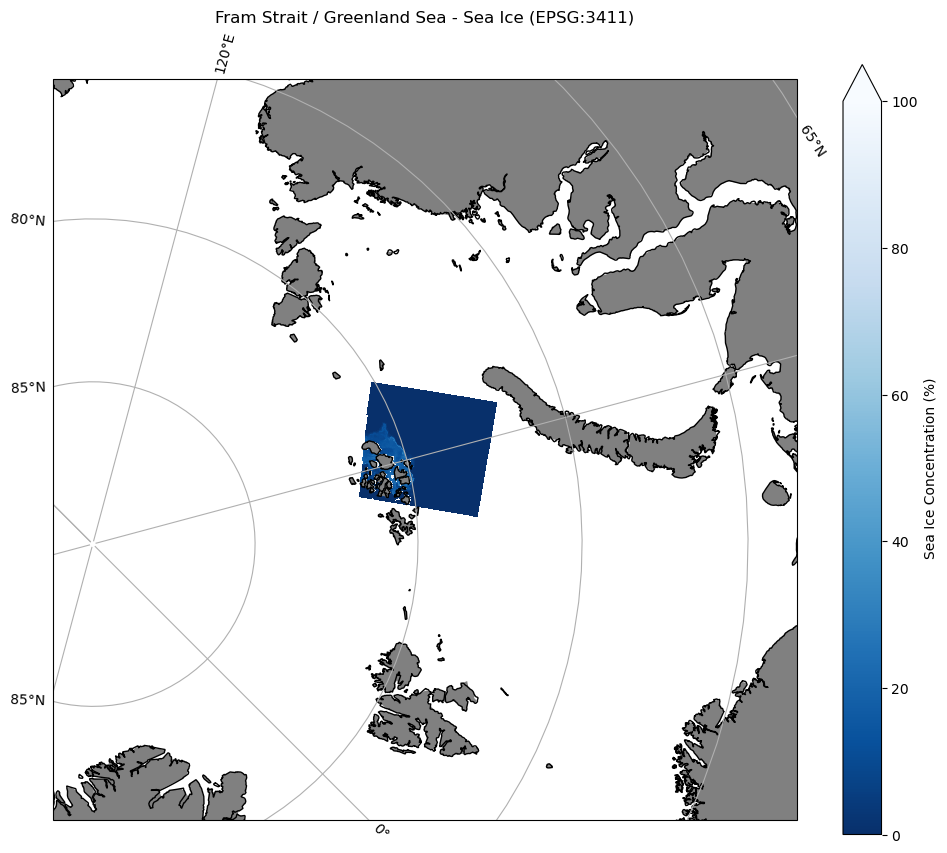

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# 1. Define the Data Projection (Source)
# Based on your spatial_ref: Central Meridian -45, Latitude of Origin 70
data_crs = ccrs.Stereographic(
    central_latitude=90, 
    central_longitude=-45, 
    true_scale_latitude=70
)
plot_data = ds_sic.isel(band =1)
# 2. Setup the Figure
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# 3. Use your New Real-World Bounds to zoom in
# Format: [minx, maxx, miny, maxy]
# We add a 50km buffer so the edges aren't cut off
minx, miny, maxx, maxy = ds_sic.rio.bounds()
ax.set_extent([minx - 1000000, maxx + 1000000, miny - 1000000, maxy + 1000000], crs=data_crs)

# 4. Add Geography
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 5. Plot the Data
# We use imshow because the grid is now regular after reprojecting
plot_data.plot.imshow(
    ax=ax,
    transform=data_crs,
    x='x', y='y',
    cmap='Blues_r',
    vmin=0, vmax=100, # Assuming SIC is 0-100%
    cbar_kwargs={'label': 'Sea Ice Concentration (%)'}
)
import cartopy.feature as cfeature

# Add this before plotting your data:
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=0)

plt.title("Fram Strait / Greenland Sea - Sea Ice (EPSG:3411)")
plt.show()

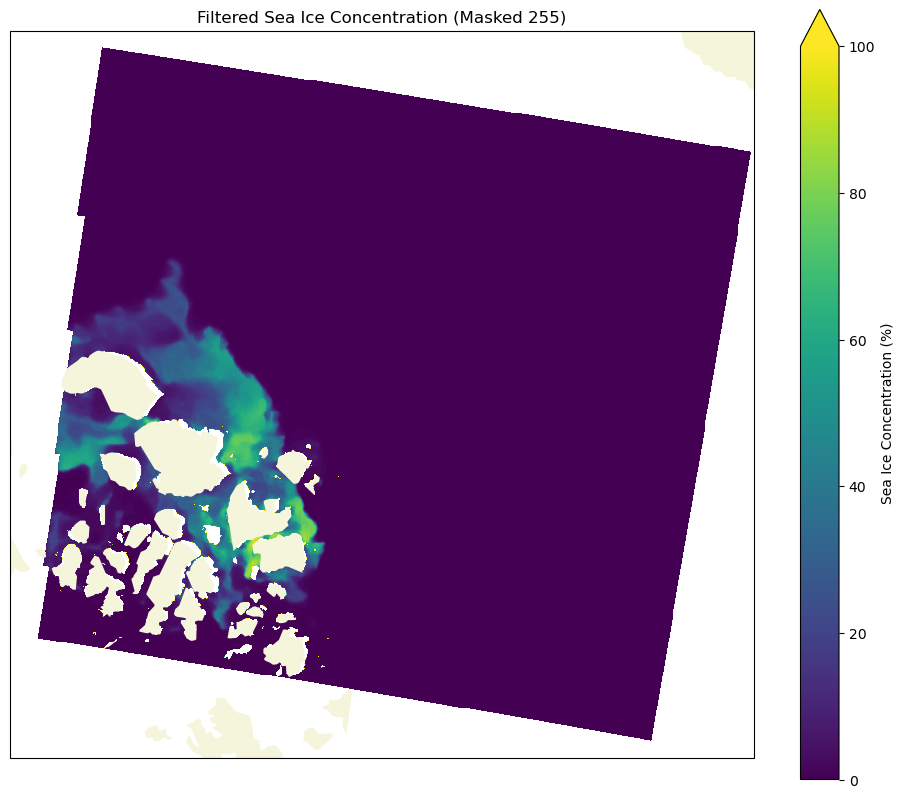

AttributeError: 'dict' object has no attribute 'plot'

<Figure size 800x600 with 0 Axes>

In [40]:
# 1. Select Band 1
band1 = ds_sic.isel(band=0)

# 2. Mask the 'No Data' value (255)
# .where() keeps data where the condition is True, and sets everything else to NaN
sic_data = band1.where(band1 != 254)

# 3. Plot with focused scale
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# Use the data_crs from before for the extent
ax.set_extent([minx, maxx, miny, maxy], crs=data_crs)
# ax.coastlines(resolution='80m', color='black')

# Now the colorbar will represent 0% to 100%
sic_data.plot.imshow(
    ax=ax,
    transform=data_crs,
    x='x', y='y',
    cmap='viridis', # Dark blue for 100%, light for 0%
    vmin=0, vmax=100,
    cbar_kwargs={'label': 'Sea Ice Concentration (%)'}
)
import cartopy.feature as cfeature

# Add this before plotting your data:
ax.add_feature(cfeature.LAND, facecolor='beige', zorder=0)

plt.title("Filtered Sea Ice Concentration (Masked 255)")
plt.show()

fig = plt.figure(figsize=(8, 6))
pixel_distribution.plot.hist(bins=bins)

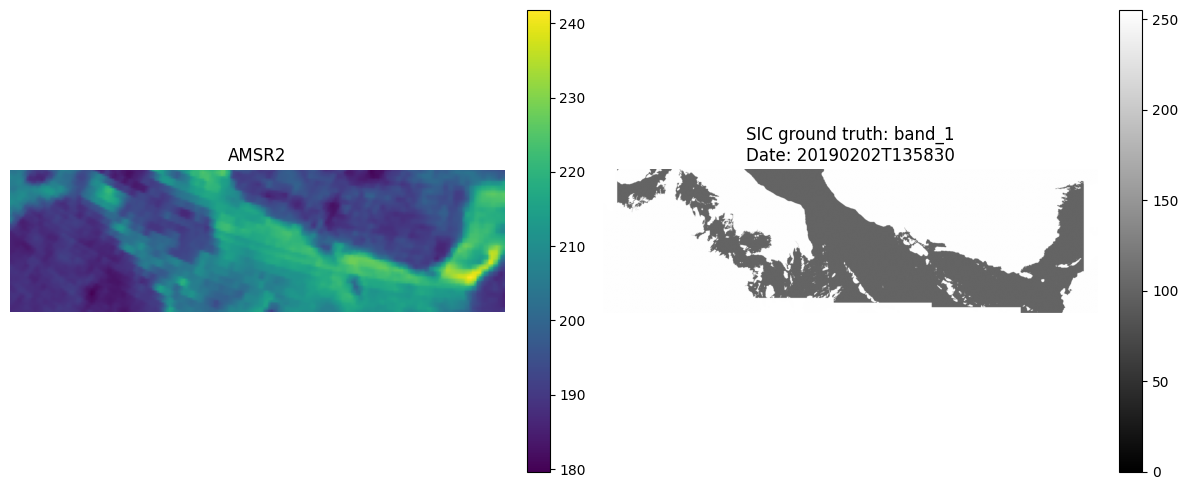

In [ ]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(amsr2['frequencies']['btemp_89.0v'], cmap='viridis')
axes[0].set_title('AMSR2')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sic['ground_truth']['band_1'], cmap='gray')
axes[1].set_title(f"SIC ground truth: {sic_name}\nDate: {sample['date']}")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()